# Validation

## Train set et Test Set

En général on va utiliser deux sets de données différents :
- train set : celui-ci va servir à l'entrainement du modèle.
- test set : celui-ci va servier à l'évaluation des performances du modèle.

Pourquoi celà ? 

Lorsqu'on teste un modèle sur les données utilisées pour l'entrainer celui-ci connais déjà ces données, et la machine va donc reconnaitre ces données.

C'est pour celà que l'on test la machine sur des données qu'elle n'a jamais vu, de cette manière on s'assure que la machine n'ai aucun biais lié à la connaissance des données et on pourra avoir une bien meilleur idée des performances de notre modèle dans la vrais vie.

On va donc toujours diviser notre dataset en deux parties. Le train set qui servira à l'entrainement de la machine et le test set qui servira à l'évaluation de celle-ci.

De manière général on tend à utiliser 80% des données dans le train set et 20% des données dans le test set.

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

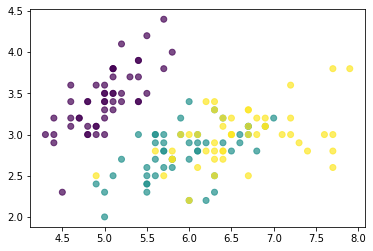

In [129]:
iris = load_iris()

X = iris.data
y = iris.target

plt.scatter(X[:,0], X[:,1], c=y, alpha=0.7)

## train_test_split

La fonction train_test_split qui se trouve dans sklearn.model_selection va nous permettre de faire ces train set et test set.

In [130]:
from sklearn.model_selection import train_test_split

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

print("Test set number of data : ", X_test.shape[0], " | ", (X_test.shape[0]/X.shape[0]) * 100, "%")
print("Train set number of data : ", X_train.shape[0], " | ", (X_train.shape[0]/X.shape[0]) * 100, "%")

Test set number of data :  38  |  25.333333333333336 %
Train set number of data :  112  |  74.66666666666667 %


L'argument test_size va nous permettre de sélectionner le pourcentage de données dans le test set.

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Test set number of data : ", X_test.shape[0], " | ", (X_test.shape[0]/X.shape[0]) * 100, "%")
print("Train set number of data : ", X_train.shape[0], " | ", (X_train.shape[0]/X.shape[0]) * 100, "%")

Test set number of data :  30  |  20.0 %
Train set number of data :  120  |  80.0 %


Text(0.5, 1.0, 'Train set')

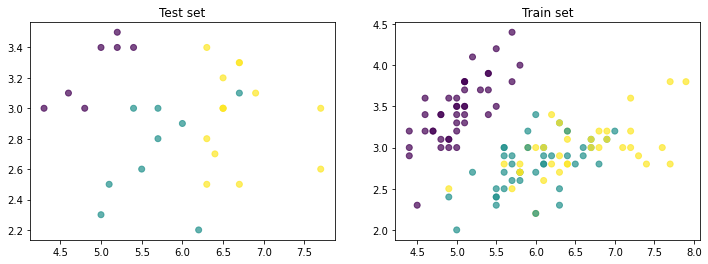

In [133]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.7)
plt.title("Test set")
plt.subplot(122)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.7)
plt.title("Train set")

La fonction train_test_split va mélanger aléatoirement le dataset et ensuite le diviser en deux set de données.

On peut utiliser l'argument random_state pour controler ce paramètre de mélange aléatoire des données.

Ce paramètre nous permettera d'avoir un résultat similaire sur un data set.

Text(0.5, 1.0, 'Train set')

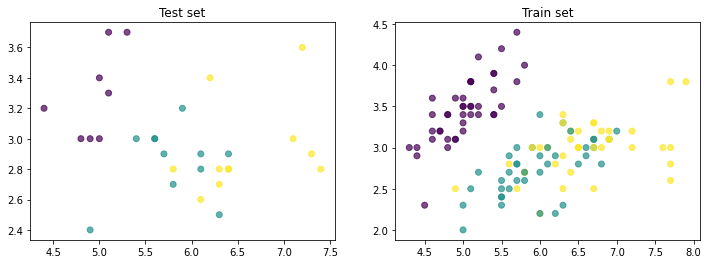

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.7)
plt.title("Test set")
plt.subplot(122)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.7)
plt.title("Train set")

Maintenant testons celà avec un modèle : 

In [135]:
from sklearn.neighbors import KNeighborsClassifier

In [136]:
model = KNeighborsClassifier(n_neighbors=1)

model.fit(X_train, y_train)
model.score(X_train, y_train)

1.0

On peut donc constater que nous avons bien un score de 1.0 lorsque nous évaluons notre modèle avec le set d'entrainement.

In [137]:
model.score(X_test, y_test)

0.9

Et un score de 0.9 lors de l'évaluation avec notre train set.

# Validation

La validation va nous servir à régler les hyper paramètre de notre modèle. Ici le but sera de trouver les paramètre obtenant le meilleur résultat par rapport.

In [138]:
for i in range(1, 10):
    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train)
    print("n_neighbors : ", i)
    print("Train set score : ", model.score(X_train, y_train))
    print("Test set score : ", model.score(X_test, y_test))
    print("-----------------------------------------------")

n_neighbors :  1
Train set score :  1.0
Test set score :  0.9
-----------------------------------------------
n_neighbors :  2
Train set score :  0.9833333333333333
Test set score :  0.9
-----------------------------------------------
n_neighbors :  3
Train set score :  0.975
Test set score :  0.9333333333333333
-----------------------------------------------
n_neighbors :  4
Train set score :  0.975
Test set score :  0.9333333333333333
-----------------------------------------------
n_neighbors :  5
Train set score :  0.9833333333333333
Test set score :  0.9333333333333333
-----------------------------------------------
n_neighbors :  6
Train set score :  0.9833333333333333
Test set score :  0.9666666666666667
-----------------------------------------------
n_neighbors :  7
Train set score :  0.9833333333333333
Test set score :  0.9666666666666667
-----------------------------------------------
n_neighbors :  8
Train set score :  0.975
Test set score :  1.0
---------------------------

Maintenant nous avons vu que changer les hyper paramètre vont influencer sur les résultats de notre test set.

Il va donc falloir faire attention, car ici nous venons de régler notre modèle par rapport au test set, et donc celui-ci est indirectement entrainer pour obtenir les meilleurs résultats avec celui-ci.

On va donc utiliser un troisième set de données. Le validation set, celui-ci va nous servir à la validation du modèle, ce sont des données qui ne devrons pas avoir été utilisées ni pour l'entrainement, ni pour le test du modèle.

On va donc créer ce nouveau set de données à partir du train set et ensuite utiliser celui-ci pour régler la machine, ce qui nous permettera de garder le test set pour l'évaluation de celle-ci.

On va donc passer par trois étapes : 
- Entrainer plusieurs modèle avec différents hyper paramètre.
- Valider ces modèle et regarder le score obtenu par ceux-ci avec le validation set.
- Tester notre modèle ayant le meilleur score avec notre test set.

In [139]:
X1_train, X1_val, y1_train, y1_val = train_test_split(X_train, y_train, test_size=0.2,random_state=5)

for i in range(1, 5):
    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X1_train, y1_train)
    print("n_neighbors : ", i)
    print("Train set score : ", model.score(X1_train, y1_train))
    print("Val set score : ", model.score(X1_val, y1_val))
    print("-----------------------------------------------")

n_neighbors :  1
Train set score :  1.0
Val set score :  0.9583333333333334
-----------------------------------------------
n_neighbors :  2
Train set score :  0.9583333333333334
Val set score :  1.0
-----------------------------------------------
n_neighbors :  3
Train set score :  0.9791666666666666
Val set score :  1.0
-----------------------------------------------
n_neighbors :  4
Train set score :  0.96875
Val set score :  0.9166666666666666
-----------------------------------------------


In [140]:
X1_train, X1_val, y1_train, y1_val = train_test_split(X_train, y_train, test_size=0.2,random_state=6)

for i in range(1, 5):
    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X1_train, y1_train)
    print("n_neighbors : ", i)
    print("Train set score : ", model.score(X1_train, y1_train))
    print("Val set score : ", model.score(X1_val, y1_val))
    print("-----------------------------------------------")

n_neighbors :  1
Train set score :  1.0
Val set score :  1.0
-----------------------------------------------
n_neighbors :  2
Train set score :  0.9791666666666666
Val set score :  0.9166666666666666
-----------------------------------------------
n_neighbors :  3
Train set score :  0.96875
Val set score :  0.9583333333333334
-----------------------------------------------
n_neighbors :  4
Train set score :  0.96875
Val set score :  0.9583333333333334
-----------------------------------------------


Il nous reste un soucis, ci-dessus, nous avons des résultats différents pour nos hyper paramètre en fonction de notre validation set.

Quel est donc le bon validation set? et quel est donc le bon modèle?

Ici nous allons utiliser une nouvel notion pour palier à ce problème, la cross validation.

## Cross Validation

La cross validation va nous permettre d'entrainer et de valider notre modèle sur plusieurs découpe possible de notre train set.

On va donc par exemple diviser notre train set en 5 parties et ensuite entrainer notre modèle sur 4 parties pour le valider sur la dernière, et ensuite on réitère l'opération avec les autres parties :
![caption](grid_search_cross_validation.png)

Une fois toutes les combinaisons possible réalisée on fera la moyenne des scores pour chaque modèle et on pourra sélectionner celui qui a obtenu la meilleure moyenne.

Il existe plusieurs manière de diviser notre set :
- KFold
- StratifiedKFol : la méthode par défaut
- ShuffleSplit
- ...

Celles-ci sont toutes détaillées sur le site de sklearn :

<a href="https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation">Cross validation</a>

![caption](sphx_glr_plot_cv_indices_0041.png) ![caption](sphx_glr_plot_cv_indices_0061.png) ![caption](sphx_glr_plot_cv_indices_0071.png) ![caption](sphx_glr_plot_cv_indices_0091.png)

Maintenant pour faire notre cross validation ce que nous devrons faire est d'importer le module cross_val_score depuis sklearn.model_selection

In [141]:
from sklearn.model_selection import cross_val_score

In [142]:
cross_val_score(KNeighborsClassifier(), X_train, y_train, cv=5, scoring='accuracy')

array([1.        , 1.        , 1.        , 0.95833333, 0.95833333])

Ici je précise que je veux utiliser l'accuracy comme scoring. Pour plus de détails sur les différents type de scoring : <a href="https://scikit-learn.org/stable/modules/classes.html?highlight=metrics#module-sklearn.metrics">scoring</a>

La sortie de cross_val_score est un tableau de score en fonction des différents splits du dataset. Je peux donc en faire la moyenne :

In [143]:
cross_val_score(KNeighborsClassifier(), X_train, y_train, cv=5, scoring='accuracy').mean()

0.9833333333333334

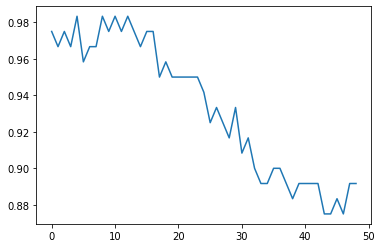

In [144]:
scores = []

for i in range(1, 50):
    score = cross_val_score(KNeighborsClassifier(i), X_train, y_train, cv=5).mean()
    scores.append(score)

plt.plot(scores)

Ici j'ai utiliser le cross_val_score pour avoir une idée du modèle obtenant le meilleur résultat sur mes données.

Et on peut voir que les meilleurs résultats sont aux allentours de 10 voisins ainsi que vers 5-6 voisins.

Maintenant est-il possible d'automatiser ces tests?? 

Biensur que oui, gràce à la fonction validation_curve.

## Validation Curve



In [145]:
from sklearn.model_selection import validation_curve

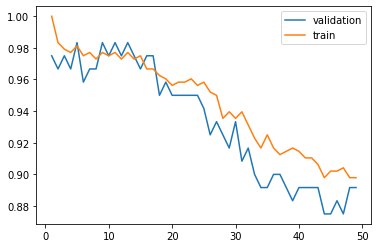

In [146]:
model = KNeighborsClassifier()
neighborsRange = np.arange(1, 50)

train_score, val_score = validation_curve(model, X_train, y_train, param_name='n_neighbors', param_range=neighborsRange, cv=5)

plt.plot(neighborsRange, val_score.mean(axis=1), label='validation')
plt.plot(neighborsRange, train_score.mean(axis=1), label='train')
plt.legend()

Ce genre de graphique vont nous permettre de détecter des soucis d'overfitting, c'est à dire quand la machine a chercher à se perfectionner de trop sur notre train set. Ce qui rendra notre modèle inutilisable. On repèrera les soucis d'overfitting quand les erreurs sur notre train set diminue mais que les erreurs de notre test set ou validation set, augmente.

Maintenant, nous n'avons pas qu'un seul hyperparamètre à tester sur notre modèle. Mais alors comment tous les tester?

Pour ce faire nous avons GridSearchCV qui va nous permettre de chercher tout seul les meilleurs combinaisons d'hyperparamètre de notre modèle.

## GirdSearchCV

GridSearchCV va nous permettre de trouver le meilleurs modèle en comparant les performances de ses différents hyperparamètre et de toutes les combinaison possible de ceux-ci.

In [147]:
from sklearn.model_selection import GridSearchCV

In [148]:
param_grid = {'n_neighbors': np.arange(1, 50), 'metric': ['euclidean', 'manhattan', 'minkowski']}

gscv = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=5)

gscv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [149]:
gscv.best_score_

0.9833333333333334

In [150]:
gscv.best_params_

{'metric': 'euclidean', 'n_neighbors': 5}

In [151]:
model = gscv.best_estimator_

model.score(X_test, y_test)

0.9333333333333333

In [152]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [153]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 8,  0,  0],
       [ 0,  9,  2],
       [ 0,  0, 11]])

<AxesSubplot:>

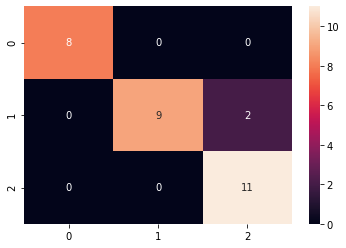

In [154]:
sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True)

# Learning curves

Les courbes d'apprentissage nous permettent de savoir le nombre optimal de donnée à fournir à notre modèle pour son apprentissage.

En effet, on pourrait se dire qu'au plus on donne de données à notre modèle au plus celui-ci sera précis, mais ce n'est pas le cas. À partir d'un certain nombre de données on touchera un plafond, une fois celui-ci atteint il est donc inutile de lui fournir plus de données, car il n'apprendra pas plus et au plus on lui fourni de données au plus lent son apprentissage sera. Mais aussi au plus récolte des données au plus celà coute cher.

In [155]:
from sklearn.model_selection import learning_curve

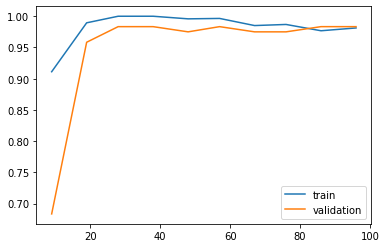

In [156]:
N, train_score, val_score = learning_curve(model, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)

plt.plot(N, train_score.mean(axis=1), label='train')
plt.plot(N, val_score.mean(axis=1), label='validation')
plt.legend()